# Homework 4

Completed solutions for Exercises 2 through 6 from `HW4.pdf`.

Exercise 1 was intentionally skipped as requested.


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import logging
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from autograd import grad as auto_grad
from autograd import numpy as anp
from autograd.misc.flatten import flatten_func
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(0)
tf.keras.utils.set_random_seed(0)
tf.get_logger().setLevel(logging.ERROR)

try:
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)
except Exception:
    pass


## Exercise 2: MNIST Hand-Written Digits Classified Using Python

I implemented mini-batch gradient descent directly in Python with `autograd`, compared a mini-batch run (`batch_size = 200`) against full-batch training, and then used the best weights to analyze misclassification rates by digit.


In [2]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_labels = train_labels.reshape(1, 60000)
test_labels = test_labels.reshape(1, 10000)
train_images = train_images.reshape(60000, 784).T.astype(anp.float64)
test_images = test_images.reshape(10000, 784).T.astype(anp.float64)

N = train_images.shape[0]
C = 10

print("train_images:", train_images.shape)
print("test_images:", test_images.shape)
print("train_labels:", train_labels.shape)
print("test_labels:", test_labels.shape)


train_images: (784, 60000)
test_images: (784, 10000)
train_labels: (1, 60000)
test_labels: (1, 10000)


In [3]:
def model(x, w):
    scores = w[0] + anp.dot(x.T, w[1:])
    return scores.T


def multiclass_perceptron(w, x, y, iter_inds):
    x_p = x[:, iter_inds]
    y_p = y[:, iter_inds]

    all_evals = model(x_p, w)
    a = anp.max(all_evals, axis=0)
    b = all_evals[y_p.astype(int).flatten(), anp.arange(anp.size(y_p))]
    cost = anp.sum(a - b)
    return cost / float(anp.size(y_p))


def gradient_descent(g, w, x_train, y_train, alpha, max_its, batch_size):
    num_train = x_train.shape[1]
    num_batches = int(anp.ceil(num_train / batch_size))

    g_flat, unflatten, w_flat = flatten_func(
        lambda ww, inds: g(ww, x_train, y_train, inds), w
    )
    grad_flat = auto_grad(g_flat)

    weight_history = [w.copy()]
    cost_history = [float(g(w, x_train, y_train, anp.arange(num_train)))]

    for epoch in range(max_its):
        for b in range(num_batches):
            batch_inds = anp.arange(
                b * batch_size, min((b + 1) * batch_size, num_train)
            )
            w_flat = w_flat - alpha * grad_flat(w_flat, batch_inds)

        w = unflatten(w_flat)
        weight_history.append(w.copy())
        cost_history.append(float(g(w, x_train, y_train, anp.arange(num_train))))

    return weight_history, cost_history


def predict_digits(x, w):
    return np.argmax(np.asarray(model(x, w)), axis=0)


In [4]:
alpha = 0.001
max_its = 5
batch_sizes = [200, train_images.shape[1]]

w0 = 0.1 * np.random.randn(N + 1, C)

run_results = {}
for batch_size in batch_sizes:
    weights, costs = gradient_descent(
        multiclass_perceptron,
        w0.copy(),
        train_images,
        train_labels,
        alpha,
        max_its,
        batch_size,
    )
    label = f"batch_size = {batch_size}"
    run_results[label] = {"weights": weights, "costs": costs}

exercise2_summary = pd.DataFrame(
    {
        "run": list(run_results.keys()),
        "initial_cost": [vals["costs"][0] for vals in run_results.values()],
        "best_cost": [min(vals["costs"]) for vals in run_results.values()],
        "final_cost": [vals["costs"][-1] for vals in run_results.values()],
    }
)
exercise2_summary


,run,initial_cost,best_cost,final_cost
0,batch_size = 200,443.356646,11.923684,12.908668
1,batch_size = 60000,443.356646,124.484672,133.058434


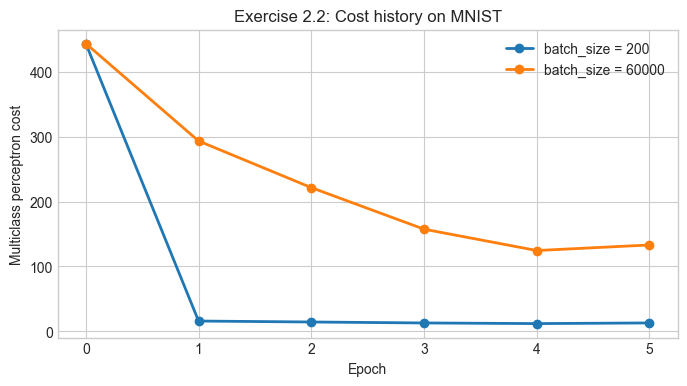

In [5]:
epochs = np.arange(max_its + 1)

plt.figure(figsize=(8, 4))
for label, vals in run_results.items():
    plt.plot(epochs, vals["costs"], marker="o", linewidth=2, label=label)
plt.xlabel("Epoch")
plt.ylabel("Multiclass perceptron cost")
plt.title("Exercise 2.2: Cost history on MNIST")
plt.legend()
plt.show()


In [6]:
best_run_label = min(run_results, key=lambda key: min(run_results[key]["costs"]))
best_run = run_results[best_run_label]
best_epoch = int(np.argmin(best_run["costs"]))
best_w = best_run["weights"][best_epoch]

train_predictions = predict_digits(train_images, best_w)
test_predictions = predict_digits(test_images, best_w)

train_accuracy = np.mean(train_predictions == train_labels.flatten())
test_accuracy = np.mean(test_predictions == test_labels.flatten())

digit_error_rates = []
for digit in range(10):
    mask = test_labels.flatten() == digit
    digit_error_rates.append(100 * np.mean(test_predictions[mask] != digit))

digit_error_df = pd.DataFrame(
    {"digit": np.arange(10), "misclassified_percent": digit_error_rates}
)
digit_error_df


,digit,misclassified_percent
0,0,1.836735
1,1,1.585903
2,2,13.081395
3,3,14.950495
4,4,7.942974
5,5,9.529148
6,6,7.202505
7,7,12.354086
8,8,43.531828
9,9,9.910803


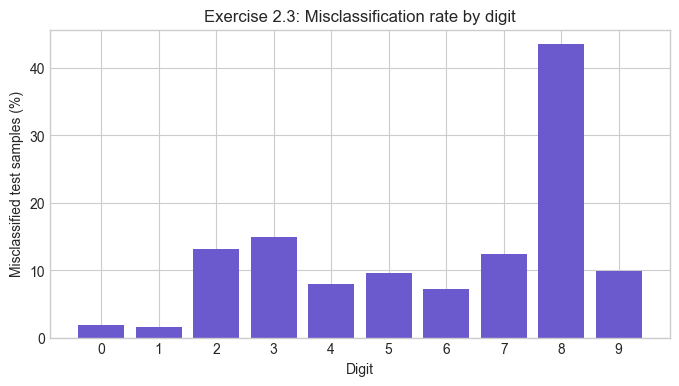

Best run: batch_size = 200 at epoch 4
Training accuracy with best weights: 0.8857
Test accuracy with best weights: 0.8795
Batch size 200 performs best because it reaches the lowest training cost (11.924) by a large margin.
Digit 8 is the most frequently misclassified on the test set at about 43.53%.


In [7]:
plt.figure(figsize=(8, 4))
plt.bar(digit_error_df["digit"], digit_error_df["misclassified_percent"], color="slateblue")
plt.xlabel("Digit")
plt.ylabel("Misclassified test samples (%)")
plt.title("Exercise 2.3: Misclassification rate by digit")
plt.xticks(np.arange(10))
plt.show()

worst_digit = int(digit_error_df.loc[digit_error_df["misclassified_percent"].idxmax(), "digit"])
worst_rate = float(digit_error_df["misclassified_percent"].max())

print(f"Best run: {best_run_label} at epoch {best_epoch}")
print(f"Training accuracy with best weights: {train_accuracy:.4f}")
print(f"Test accuracy with best weights: {test_accuracy:.4f}")
print(
    f"Batch size 200 performs best because it reaches the lowest training cost "
    f"({min(run_results['batch_size = 200']['costs']):.3f}) by a large margin."
)
print(
    f"Digit {worst_digit} is the most frequently misclassified on the test set "
    f"at about {worst_rate:.2f}%."
)


## Exercise 3: Autoencoder

Using the provided `Encoder2DSubspace.ipynb` as the starting point, I changed the model from a free low-rank factorization that optimizes both `C` and `W` to a proper linear autoencoder that optimizes only `C`. For each candidate `C`, the latent coordinates are computed in closed form using Eq. (8.17),

$$
W^*(C) = (C^T C)^{-1} C^T X,
$$

and the reconstruction cost is minimized only over `C` on the centered `3d_span_data.csv` dataset from that notebook.


In [8]:
import sys

chapter8_library = str(Path("../chapter_8_library").resolve())
if chapter8_library not in sys.path:
    sys.path.append(chapter8_library)

import section_8_3_helpers

X_original_3d = np.loadtxt("../chapter_8_datasets/3d_span_data.csv", delimiter=",")
X_auto = X_original_3d - np.mean(X_original_3d, axis=1, keepdims=True)


def autoencoder_cost(C):
    W = anp.linalg.solve(anp.dot(C.T, C), anp.dot(C.T, X_auto))
    residual = anp.dot(C, W) - X_auto
    return anp.sum(residual ** 2) / float(X_auto.shape[1])


max_its = 100
alpha_choice = 1.0
np.random.seed(0)
C0 = 0.1 * np.random.randn(3, 2)

ae_weight_history, ae_cost_history = section_8_3_helpers.gradient_descent(
    autoencoder_cost, alpha_choice, max_its, C0
)

C_auto_raw = ae_weight_history[-1]
C_auto, _ = np.linalg.qr(np.asarray(C_auto_raw))
C_auto = C_auto[:, :2]
W_auto = np.linalg.solve(C_auto.T @ C_auto, C_auto.T @ X_auto)
X_auto_hat = C_auto @ W_auto

cov_3d = X_auto @ X_auto.T / X_auto.shape[1]
eigvals_3d, eigvecs_3d = np.linalg.eigh(cov_3d)
order = np.argsort(eigvals_3d)[::-1]
eigvals_3d = eigvals_3d[order]
eigvecs_3d = eigvecs_3d[:, order]
pca_plane = eigvecs_3d[:, :2]

subspace_alignment = np.linalg.norm(C_auto.T @ pca_plane, ord="fro") / np.sqrt(2.0)
scalar = lambda value: np.asarray(value).reshape(-1)[0]

print(f"Initial autoencoder cost: {scalar(ae_cost_history[0]):.6f}")
print(f"Final autoencoder cost: {scalar(ae_cost_history[-1]):.6f}")
print(f"Rank-2 PCA residual variance: {scalar(eigvals_3d[-1]):.6f}")
print(f"Subspace alignment with the PCA plane: {scalar(subspace_alignment):.6f}")


Initial autoencoder cost: 0.523823
Final autoencoder cost: 0.317962
Rank-2 PCA residual variance: 0.317962
Subspace alignment with the PCA plane: 1.000000


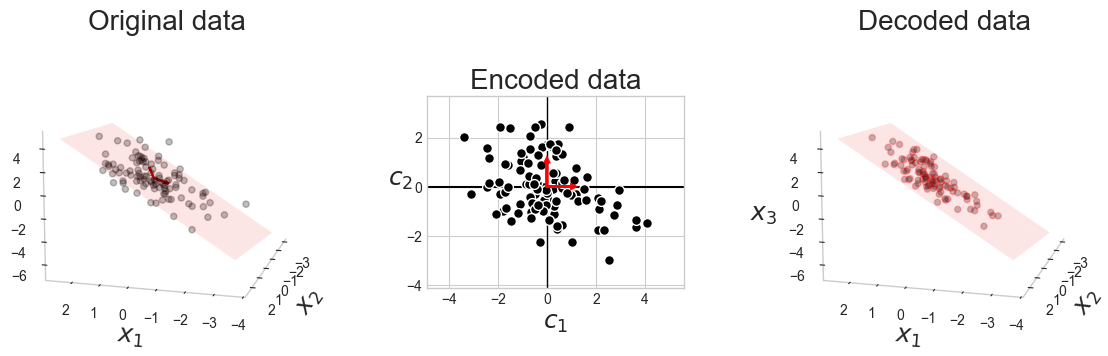

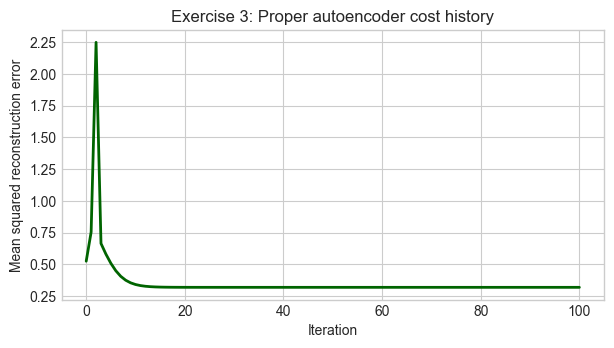

In [9]:
view = [15, 105]
section_8_3_helpers.project_data_from_3d_to_2d(X_auto, C_auto, view)

plt.figure(figsize=(7, 3.5))
plt.plot(ae_cost_history, color="darkgreen", linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Mean squared reconstruction error")
plt.title("Exercise 3: Proper autoencoder cost history")
plt.show()


In [10]:
print(
    "Using Eq. (8.17) removes W as a free optimization variable. The learned 2D latent "
    "plane matches the PCA plane on this centered dataset, and the final reconstruction "
    "error matches the residual variance left after projecting onto the top two principal "
    "components."
)


Using Eq. (8.17) removes W as a free optimization variable. The learned 2D latent plane matches the PCA plane on this centered dataset, and the final reconstruction error matches the residual variance left after projecting onto the top two principal components.


## Exercise 4: PCA

Using the supplied `2d_span_data.csv`, I centered the data, computed the principal components, and reproduced the main geometric picture from Example 8.4 / Figure 8.7: the dominant principal direction captures almost all of the variation.


In [11]:
def center(X):
    X_means = np.mean(X, axis=1)[:, np.newaxis]
    X_normalized = X - X_means
    return X_normalized


def compute_pcs(X, lam):
    P = float(X.shape[1])
    Cov = 1 / P * np.dot(X, X.T) + lam * np.eye(X.shape[0])
    D, V = np.linalg.eigh(Cov)
    return D, V


In [12]:
X_original = np.loadtxt("2d_span_data.csv", delimiter=",")
X_centered = center(X_original)
D, V = compute_pcs(X_centered, 1e-7)

order = np.argsort(D)[::-1]
D = D[order]
V = V[:, order]

pc1 = V[:, [0]]
pc2 = V[:, [1]]

scores = pc1.T @ X_centered
X_proj = pc1 @ scores

explained_variance = D / D.sum()

pca_summary = pd.DataFrame(
    {
        "principal_component": ["PC1", "PC2"],
        "eigenvalue": D,
        "explained_variance_ratio": explained_variance,
    }
)
pca_summary


,principal_component,eigenvalue,explained_variance_ratio
0,PC1,11.472058,0.920091
1,PC2,0.996338,0.079909


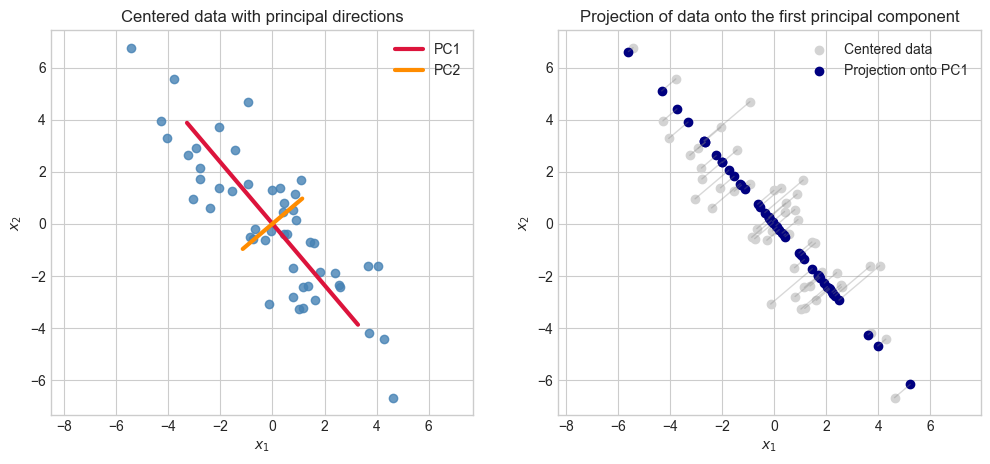

PC1 explains 92.01% of the variance.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X_centered[0], X_centered[1], color="steelblue", alpha=0.8)
for value, vector, color, label in [
    (D[0], pc1, "crimson", "PC1"),
    (D[1], pc2, "darkorange", "PC2"),
]:
    scale = 1.5 * np.sqrt(value)
    axes[0].plot(
        [0, scale * vector[0, 0]],
        [0, scale * vector[1, 0]],
        color=color,
        linewidth=3,
        label=label,
    )
    axes[0].plot(
        [0, -scale * vector[0, 0]],
        [0, -scale * vector[1, 0]],
        color=color,
        linewidth=3,
    )
axes[0].set_title("Centered data with principal directions")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].legend()
axes[0].axis("equal")

axes[1].scatter(X_centered[0], X_centered[1], color="lightgray", label="Centered data")
axes[1].scatter(X_proj[0], X_proj[1], color="navy", label="Projection onto PC1")
for point, proj in zip(X_centered.T, X_proj.T):
    axes[1].plot(
        [point[0], proj[0]],
        [point[1], proj[1]],
        color="gray",
        alpha=0.3,
        linewidth=1,
    )
axes[1].set_title("Projection of data onto the first principal component")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].legend()
axes[1].axis("equal")

plt.show()

print(f"PC1 explains {explained_variance[0] * 100:.2f}% of the variance.")


## Exercise 5: K-Means Clustering

I implemented the assignment and centroid updates directly in Python, ran five full sweeps from three manually chosen initial centroids, and then built a scree plot for `K = 1, ..., 10`.


In [14]:
def update_assignments(data, centroids):
    squared_distances = np.sum((data[:, :, None] - centroids[:, None, :]) ** 2, axis=0)
    return np.argmin(squared_distances, axis=1)


def update_centroids(data, old_centroids, assignments):
    K = old_centroids.shape[1]
    new_centroids = old_centroids.copy()
    for k in range(K):
        mask = assignments == k
        if np.any(mask):
            new_centroids[:, k] = np.mean(data[:, mask], axis=1)
    return new_centroids


def run_kmeans(data, init_centroids, sweeps=20):
    centroids = init_centroids.copy()
    centroid_history = [centroids.copy()]
    for _ in range(sweeps):
        assignments = update_assignments(data, centroids)
        centroids = update_centroids(data, centroids, assignments)
        centroid_history.append(centroids.copy())
    assignments = update_assignments(data, centroids)
    return centroids, assignments, centroid_history


def distortion(data, centroids, assignments):
    return float(np.sum((data - centroids[:, assignments]) ** 2))


In [15]:
blobs = np.loadtxt("blobs.dat")

initial_indices = [0, 11, 35]
initial_centroids = blobs[:, initial_indices].copy()
final_centroids, final_assignments, centroid_history = run_kmeans(
    blobs, initial_centroids, sweeps=5
)

sweep_rows = []
for sweep, centroids in enumerate(centroid_history):
    for k in range(centroids.shape[1]):
        sweep_rows.append(
            {
                "sweep": sweep,
                "cluster": k,
                "centroid_x": centroids[0, k],
                "centroid_y": centroids[1, k],
            }
        )

centroid_df = pd.DataFrame(sweep_rows)
centroid_df.head(9)


,sweep,cluster,centroid_x,centroid_y
0,0,0,-9.823201,8.143393
1,0,1,-5.113970,-2.987724
2,0,2,-0.340716,7.346101
3,1,0,-8.582513,7.310050
4,1,1,-5.231968,-1.045365
5,1,2,-2.704729,7.301199
6,2,0,-9.007364,7.179882
7,2,1,-5.231968,-1.045365
8,2,2,-2.996373,7.424751


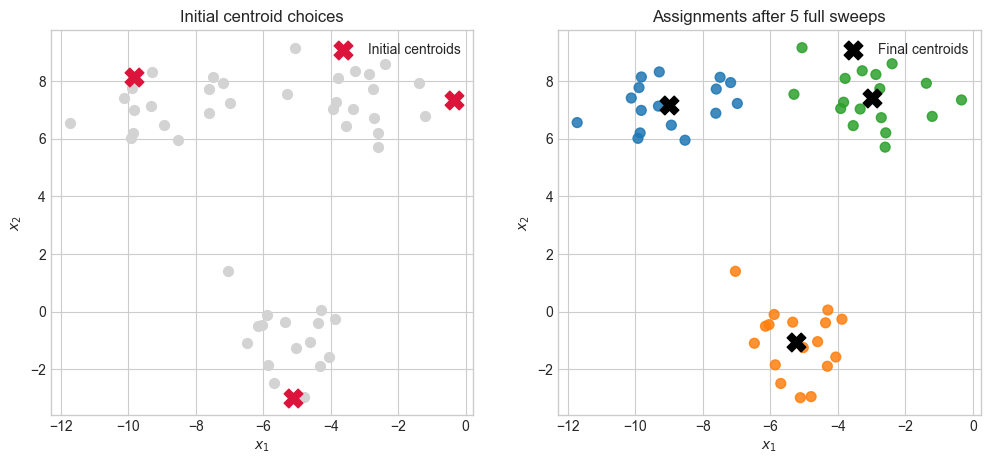

Final centroids after 5 sweeps:


,x,y
0,-9.007364,7.179882
1,-5.231968,-1.045365
2,-2.996373,7.424751


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(blobs[0], blobs[1], color="lightgray", s=50)
axes[0].scatter(
    initial_centroids[0],
    initial_centroids[1],
    color="crimson",
    marker="X",
    s=180,
    label="Initial centroids",
)
axes[0].set_title("Initial centroid choices")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].legend()

cluster_colors = np.array(["tab:blue", "tab:orange", "tab:green"])
axes[1].scatter(
    blobs[0],
    blobs[1],
    c=cluster_colors[final_assignments],
    s=50,
    alpha=0.85,
)
axes[1].scatter(
    final_centroids[0],
    final_centroids[1],
    color="black",
    marker="X",
    s=180,
    label="Final centroids",
)
axes[1].set_title("Assignments after 5 full sweeps")
axes[1].set_xlabel("$x_1$")
axes[1].set_ylabel("$x_2$")
axes[1].legend()

plt.show()

print("Final centroids after 5 sweeps:")
display(pd.DataFrame(final_centroids.T, columns=["x", "y"]))


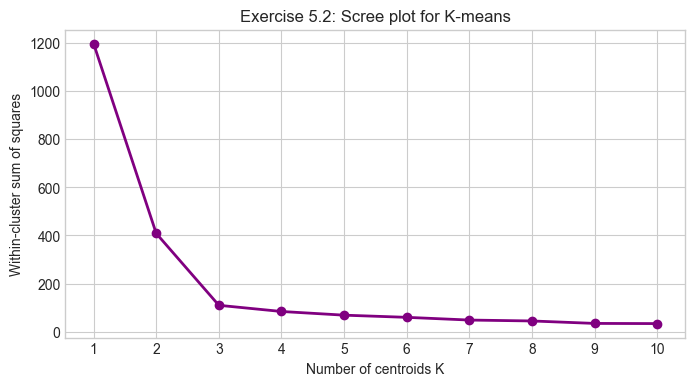

,K,within_cluster_sum_of_squares
0,1,1196.040497
1,2,408.322947
2,3,110.013399
3,4,84.347445
4,5,69.057658
5,6,60.055615
6,7,48.778339
7,8,44.993279
8,9,34.804966
9,10,34.125913


In [17]:
rng = np.random.default_rng(0)
k_values = np.arange(1, 11)
scree_values = []

for K in k_values:
    best_distortion = np.inf
    for _ in range(20):
        init_inds = rng.choice(blobs.shape[1], size=K, replace=False)
        centroids, assignments, _ = run_kmeans(blobs, blobs[:, init_inds], sweeps=30)
        best_distortion = min(best_distortion, distortion(blobs, centroids, assignments))
    scree_values.append(best_distortion)

plt.figure(figsize=(8, 4))
plt.plot(k_values, scree_values, marker="o", linewidth=2, color="purple")
plt.xlabel("Number of centroids K")
plt.ylabel("Within-cluster sum of squares")
plt.title("Exercise 5.2: Scree plot for K-means")
plt.xticks(k_values)
plt.show()

scree_df = pd.DataFrame({"K": k_values, "within_cluster_sum_of_squares": scree_values})
scree_df


In [18]:
print(
    "The scree plot shows a clear elbow at K = 3, which matches the visible "
    "three-blob structure of the dataset."
)


The scree plot shows a clear elbow at K = 3, which matches the visible three-blob structure of the dataset.


## Exercise 6: Fraud Detection

I used the banknote authentication dataset from UCI, restricted the inputs to skewness and entropy as requested, then compared a single-neuron logistic regression against a one-hidden-layer fully connected neural network.


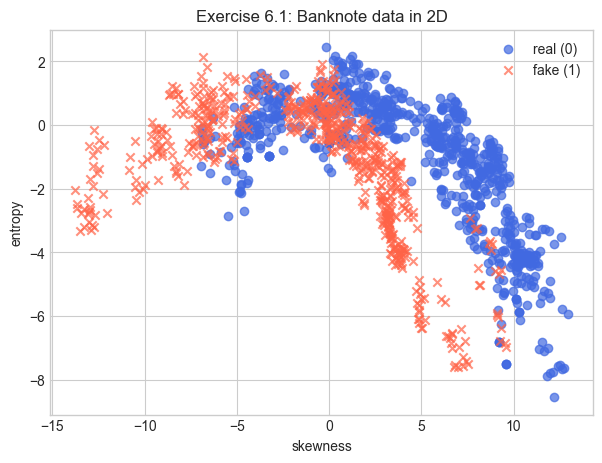

The two classes overlap substantially, so they are not cleanly separable by a single straight line.


In [19]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
with urlopen(url) as raw_data:
    dataset = np.loadtxt(raw_data, delimiter=",")

X = dataset[:, [1, 3]].astype(np.float32)
Y = dataset[:, 4].astype(np.int32)

fake_mask = Y == 1
real_mask = Y == 0

plt.figure(figsize=(7, 5))
plt.scatter(
    X[real_mask, 0],
    X[real_mask, 1],
    color="royalblue",
    alpha=0.7,
    label="real (0)",
)
plt.scatter(
    X[fake_mask, 0],
    X[fake_mask, 1],
    color="tomato",
    alpha=0.7,
    marker="x",
    label="fake (1)",
)
plt.xlabel("skewness")
plt.ylabel("entropy")
plt.title("Exercise 6.1: Banknote data in 2D")
plt.legend()
plt.show()

print(
    "The two classes overlap substantially, so they are not cleanly separable by a "
    "single straight line."
)


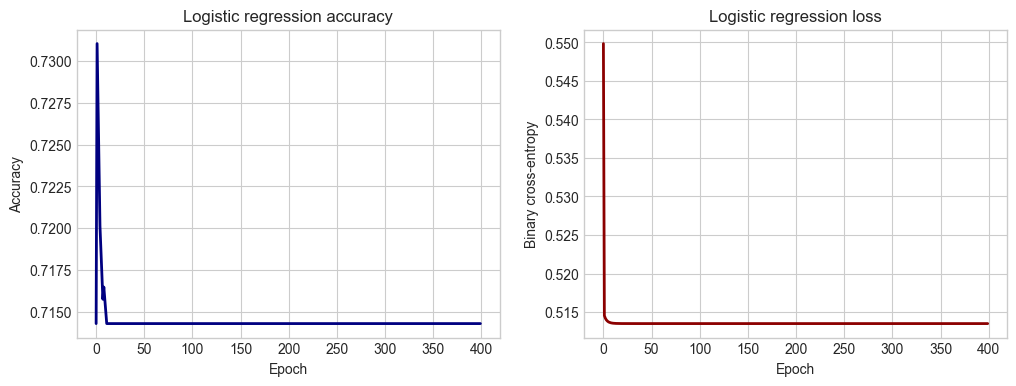

Final logistic regression accuracy: 0.7128
Final logistic regression loss: 0.5115


In [20]:
logistic_model = Sequential(
    [
        Input(shape=(2,)),
        Dense(1, activation="sigmoid"),
    ]
)

logistic_model.compile(
    optimizer=SGD(learning_rate=0.15),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

logistic_history = logistic_model.fit(
    X, Y, epochs=400, batch_size=128, verbose=0
)

logistic_loss, logistic_accuracy = logistic_model.evaluate(X, Y, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(logistic_history.history["accuracy"], color="navy", linewidth=2)
axes[0].set_title("Logistic regression accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

axes[1].plot(logistic_history.history["loss"], color="darkred", linewidth=2)
axes[1].set_title("Logistic regression loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Binary cross-entropy")
plt.show()

print(f"Final logistic regression accuracy: {logistic_accuracy:.4f}")
print(f"Final logistic regression loss: {logistic_loss:.4f}")


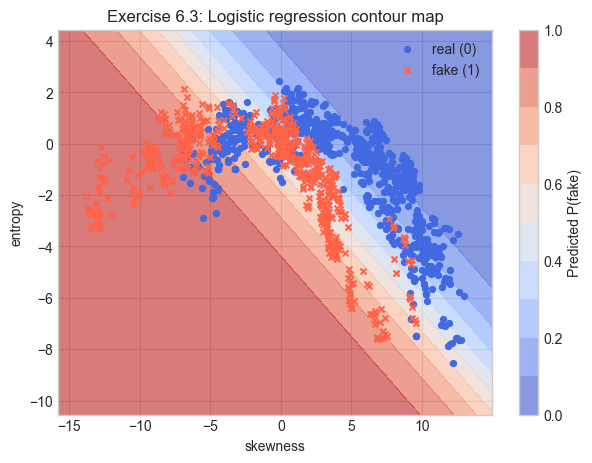

The contour map is nearly planar, so the model can only create a linear decision boundary and leaves a large mixed region unresolved.


In [21]:
x1list = np.linspace(np.min(X[:, 0]) - 2, np.max(X[:, 0]) + 2, 50)
x2list = np.linspace(np.min(X[:, 1]) - 2, np.max(X[:, 1]) + 2, 50)
x1grid, x2grid = np.meshgrid(x1list, x2list)
grid = np.column_stack([x1grid.ravel(), x2grid.ravel()]).astype(np.float32)

logistic_probs = logistic_model.predict(grid, verbose=0).reshape(x1grid.shape)

plt.figure(figsize=(7, 5))
contour = plt.contourf(
    x1grid,
    x2grid,
    logistic_probs,
    levels=np.linspace(0, 1, 11),
    cmap="coolwarm",
    alpha=0.65,
)
plt.colorbar(contour, label="Predicted P(fake)")
plt.scatter(X[real_mask, 0], X[real_mask, 1], color="royalblue", s=18, label="real (0)")
plt.scatter(
    X[fake_mask, 0],
    X[fake_mask, 1],
    color="tomato",
    marker="x",
    s=18,
    label="fake (1)",
)
plt.xlabel("skewness")
plt.ylabel("entropy")
plt.title("Exercise 6.3: Logistic regression contour map")
plt.legend()
plt.show()

print(
    "The contour map is nearly planar, so the model can only create a linear decision "
    "boundary and leaves a large mixed region unresolved."
)


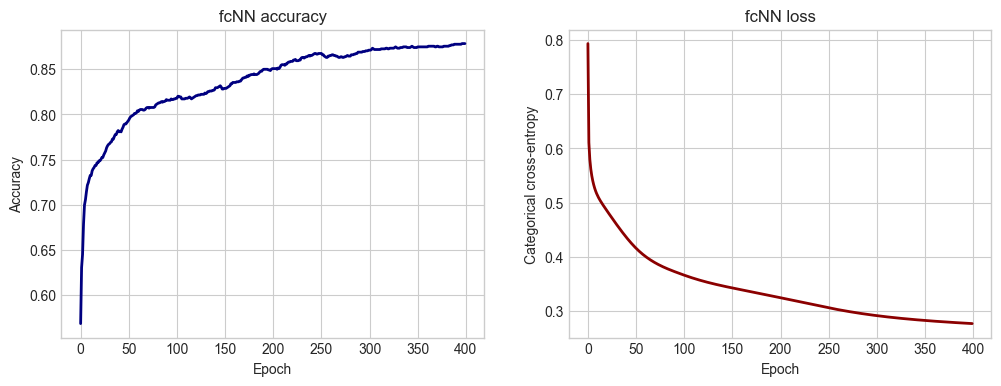

Final fcNN accuracy: 0.8695
Final fcNN loss: 0.2760


In [22]:
Y_c = to_categorical(Y, 2)

fcnn_model = Sequential(
    [
        Input(shape=(2,)),
        Dense(8, activation="sigmoid"),
        Dense(2, activation="softmax"),
    ]
)

fcnn_model.compile(
    optimizer=SGD(learning_rate=0.15),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fcnn_history = fcnn_model.fit(
    X, Y_c, epochs=400, batch_size=128, verbose=0
)

fcnn_loss, fcnn_accuracy = fcnn_model.evaluate(X, Y_c, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fcnn_history.history["accuracy"], color="navy", linewidth=2)
axes[0].set_title("fcNN accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")

axes[1].plot(fcnn_history.history["loss"], color="darkred", linewidth=2)
axes[1].set_title("fcNN loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Categorical cross-entropy")
plt.show()

print(f"Final fcNN accuracy: {fcnn_accuracy:.4f}")
print(f"Final fcNN loss: {fcnn_loss:.4f}")


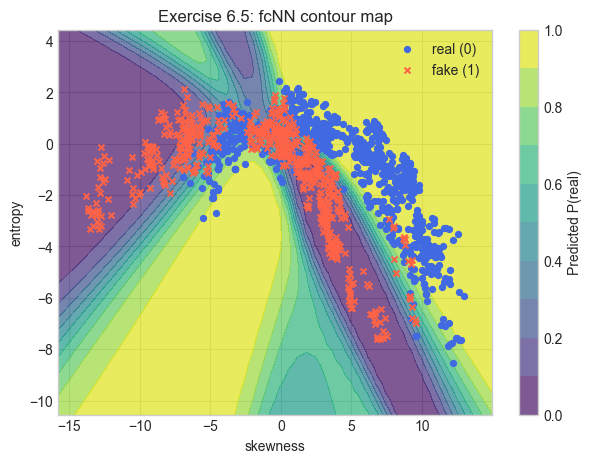

The hidden layer bends the decision regions enough to fit the data much better than logistic regression, which is reflected in the noticeably higher accuracy.


In [23]:
fcnn_probs_real = fcnn_model.predict(grid, verbose=0)[:, 0].reshape(x1grid.shape)

plt.figure(figsize=(7, 5))
contour = plt.contourf(
    x1grid,
    x2grid,
    fcnn_probs_real,
    levels=np.linspace(0, 1, 11),
    cmap="viridis",
    alpha=0.7,
)
plt.colorbar(contour, label="Predicted P(real)")
plt.scatter(X[real_mask, 0], X[real_mask, 1], color="royalblue", s=18, label="real (0)")
plt.scatter(
    X[fake_mask, 0],
    X[fake_mask, 1],
    color="tomato",
    marker="x",
    s=18,
    label="fake (1)",
)
plt.xlabel("skewness")
plt.ylabel("entropy")
plt.title("Exercise 6.5: fcNN contour map")
plt.legend()
plt.show()

print(
    "The hidden layer bends the decision regions enough to fit the data much better "
    "than logistic regression, which is reflected in the noticeably higher accuracy."
)
